In [1]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def differential_equation(t:torch.Tensor, y:torch.Tensor):
    a: float = 2.0
    b: float = 1.0
    
    #return r*t*(1-t)
    return a*y+b

def solution(x):
    return torch.exp(2*x) - 1/2

In [3]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    def __init__(self, input_size: int = 1, output_size: int = 1, hidden_layers: int = 5, hidden_nodes: int = 10):
        super().__init__()
        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)])
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    def forward(self, t: torch.Tensor):
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t


In [4]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 1, 100).reshape(-1, 1) #many data points
y = solution(x).reshape(-1, 1) #analytical solution for the differential equation

#take only certain points for training
x_data = x[0:200:20]
y_data = y[0:200:20]

#move tensors to the selected device
x_data_t = x_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)
y_data_t = y_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)

#creating points for physics loss
x_physics = torch.linspace(0, 1, 100, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

In [5]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
Epochs = 20000
Length = 1e4

model = PINNModel().to(device)
optimize = torch.optim.Adam(model.parameters(), lr=1e-3)

data_loss = nn.MSELoss()

for epoch in range(Epochs):
    optimize.zero_grad()
    
    #data loss
    y_pred = model(x_data_t)
    loss_data = data_loss(y_pred, y_data_t)

    #physics loss
    y_physics = model(x_physics)
    dy_physics = ag.grad(y_physics, x_physics, torch.ones_like(y_physics), create_graph=True)[0]
    physics = dy_physics - differential_equation(x_physics, y_physics)
    loss_physics = torch.mean(physics**2)
    total_loss = loss_data + loss_physics

    total_loss.backward()
    optimize.step()
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Data Loss: {loss_data.item()}, Physics Loss: {loss_physics.item()}")

Epoch: 0, Total Loss: 7.60819673538208, Data Loss: 6.770540714263916, Physics Loss: 0.8376560211181641
Epoch: 1000, Total Loss: 0.0005625251214951277, Data Loss: 0.00014329545956570655, Physics Loss: 0.00041922967648133636
Epoch: 2000, Total Loss: 0.0005423947004601359, Data Loss: 3.207221016054973e-05, Physics Loss: 0.000510322512127459
Epoch: 3000, Total Loss: 4.301025910535827e-05, Data Loss: 4.4821189248978044e-07, Physics Loss: 4.2562045564409345e-05
Epoch: 4000, Total Loss: 2.1267418560455553e-05, Data Loss: 1.3952634958513954e-07, Physics Loss: 2.112789297825657e-05
Epoch: 5000, Total Loss: 1.3676944035978522e-05, Data Loss: 7.273585111988723e-08, Physics Loss: 1.3604208106698934e-05
Epoch: 6000, Total Loss: 4.958784120390192e-05, Data Loss: 2.8380422918417025e-06, Physics Loss: 4.6749799366807565e-05
Epoch: 7000, Total Loss: 8.897274710761849e-06, Data Loss: 3.610134058362746e-08, Physics Loss: 8.861173228069674e-06
Epoch: 8000, Total Loss: 7.080573141138302e-06, Data Loss: 2.3

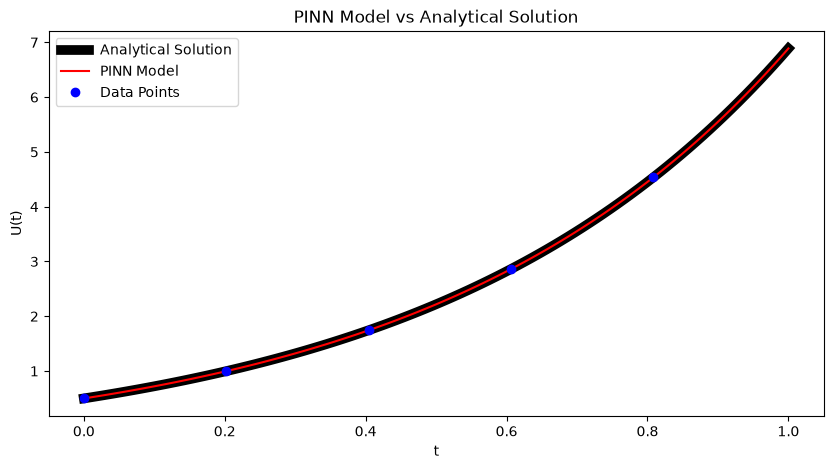

In [6]:
#Testing the Model
model.eval()
x_test = x.detach().clone().to(device=device, dtype=torch.float32)
y_pred = model(x_test).detach().cpu().numpy().reshape(-1, 1)

#Plotting the Neural Network Model vs Analytical Solution
plt.figure(figsize=(10, 5))
plt.title("PINN Model vs Analytical Solution")
plt.plot(x, y, label="Analytical Solution", color="black", linewidth=7)
plt.xlabel("t")
plt.ylabel("U(t)")

#plotting the analytical solution
plt.plot(x, y_pred, label="PINN Model", color="red")

#plotting the training data points
plt.plot(x_data, y_data, label="Data Points", color="blue", linestyle="None", marker="o")
plt.legend()
plt.show()